<style>
div.highlight pre {
    background: #ffffff !important;
    color: #000000 !important;
}

code {
    background-color: #f5f5f5 !important;
    color: #000000 !important;
}
</style>

# Análisis de Algoritmos de Ordenamiento y Sweep Line
### **Alumno:** Sergio de Carlo Rodríguez Hernández  
### **Materia:** Programación   
### **Fecha:** 07/04/2026  

# Análisis de Algoritmos de Ordenamiento

## 1. Introducción

El ordenamiento de datos es uno de los problemas fundamentales en ciencias de la computación, con aplicaciones en múltiples áreas como búsqueda, optimización y análisis de información. La eficiencia de los algoritmos de ordenamiento impacta directamente en el rendimiento de sistemas que manejan grandes volúmenes de datos.

En este trabajo se analizan e implementan distintos algoritmos de ordenamiento, con el objetivo de comparar su desempeño teórico y práctico. Se consideran tanto algoritmos clásicos como enfoques más eficientes, así como una aplicación del paradigma de eventos mediante el uso de sweep line algorithms.

---



## 2. Métodos

### 2.1 Descripción de Algoritmos

A continuación se describen los algoritmos implementados:




#### Bubble Sort

En cada pasada, el elemento más grande “flota” hacia el final del arreglo,
como una burbuja que sube a la superficie, de ahí el nombre.

Después de la primera pasada:

- el mayor elemento queda en la última posición.

Después de la segunda pasada:

- el segundo mayor queda en la penúltima posición.

Y así sucesivamente.

##### Ejemplo


In [60]:
def bubble_sort(list_n):
    # Copiamos la lista para no modificar el objeto original
    list_n_sorted = list_n.copy()
    # Asignamos el numero de elementos
    n = len(list_n_sorted)

    # Primera iteración sobre cada elemento en la lista, que será el primer valor a comprar con la entera lista
    for i in range(n):
        # Segunda iteración, la cual se moverá n*n; es decir si n=10, se moverá 10 veces, cada ciclo de n, = 100(en el ccaso normal)
        for j in range(0,n-1-i): # Determinos que se mueva hasta n-1, ya que para hacer el swap hacemos j+1, lo que permite acceder al indice adelantado y evita desbordamiento de memoria
             # Como se mencionó antes, se harían n*n operaciones, sin embargo, si sabemos que cada operación deja el más grande al final, entonces podemos ir omitiendo ese, entonces -i
            if list_n_sorted[j]>list_n_sorted[j+1]: #Comparamos si el elemento en el indice j, es mayor al del indice j+1
                #Si es así, entonces hacemos el swap en la misma linea mediante la característica de unpacking, de este modo no usamos temp
                list_n_sorted[j+1],list_n_sorted[j] = list_n_sorted[j],list_n_sorted[j+1]
    return list_n_sorted
                


#### Selection Sort

El ordenamiento por seleccion funciona buscando el elemento más pequeño del arreglo y colocandolo directamente en su posición corrcta.
A diferencia del método de burbuja:
- No intercambia constantemente
- Hace exactamente un intercambio por pasada(cómo máximo)
##### Ejemplo

Imagina que tienes una fila de cartas desordenadas
1. Busca la carta más pequeña
2. La intercambias por la primera posición
3. Repoites el proceso, pero ahora ignorando la parte ya ordenada
Cada pasada __Fija un elemento en su posición definitiva__


In [71]:
def selection_sort(list_n):
    #Copiamos la lista para no sobreescribir la original
    list_n_sorted = list_n.copy()
    # Asignamos a n la cantidad de valores en la lista
    n = len(list_n_sorted)
    for i in range(n): # Itreamos en un rango de 0 - n, excluyendo n
        
        aux_min,aux_pos = list_n_sorted[i],i #Guardamos en variables auxiliares el valor de la lista en el indice i, y su indice
        
        for j in range(0+i,n): # Iteramos nuevamente sobre un rango de valores de 0+i(Para no iterar sobre los valores ya sobreescritos), hasta n, n excluido
            if aux_min > list_n_sorted[j]: # Validamos si nuestra minmo auxiliar es mayor al valor en el indice j
                aux_min,aux_pos = list_n_sorted[j],j # Sobreescribimos aux_min, y aux_pos, ya que encontramos otro más pequeño
        list_n_sorted[0+i],list_n_sorted[aux_pos] = aux_min,list_n_sorted[0+i] # Hacemos el swap en la misma linea teniendo en cuenta el indice al corriente
    return list_n_sorted




#### Counting Sort

El ordenamiento por conteo __no compara elementos entre sí.__
En lugar de eso:
__Cuenta cuántas veces aparece cada valor.__
Usa esa información para reconstruir el arreglo ordenado

Funciona __solo cuanod los valores son enteros__ y __pertenecen a un rango pequeño y conocido __

Sea un arreglo __A__ de tamaño __n__, con valores entre __0__ y __k__

1. Inicializa el arreglo de conteo
2. Contar ocurrencias
3. Reconstruir arreglo ordenado

##### Ejemplo

Imagina calificaciones de un examen: [6,8,5,8,6,7]
Sabemos que las calificaciones posibles son: 5,6,7,8

Cuenta cuantos __5,6,7,8__ hay.

Reconstruimos el arrego: [5,6,6,7,8,8]

In [76]:
def counting_sort(list_n):
    #Copiamos la lista original para no sobreescribir sus datos en memoria
    list_n_sorted = []
    #Creamos un diccionario, que automaticamente nos deja los unicos valores como llaves e inciializamos su contador en 0
    dx_key_count = {no:0 for no in list_n}
    for key in dx_key_count.keys(): # Iteramos sobre cada llave del diccionario
        for n in list_n: # Iteramos sobre cada valor en la lista
            if n == key: # Si n es exactamente igual a nuestra llave, entonces le sumamos uno al valor que apunta
                dx_key_count[key] += 1

    sorted_keys = bubble_sort(list(dx_key_count.keys())) #Sorteamos con el método de burbuja previamente definido
    
    for key in sorted_keys: #Iteramos sobre cada llave ya ordenada
        for time in range(dx_key_count[key]):# Iteramos sobre un rango que se crea dinamicamente mediante el valor al que apunta la key del diccionario, 
            list_n_sorted.append(key)# Iteramos n veces el rango y por cada n veces es la ves que añadiremos el valor, que corresponde a la reconstrucción de la lista
            
    return list_n_sorted
    
    

#### Quick Sort

Ordena un arreglo dividiéndolo __recursivamente__ alrededor de un elemento especial llamado __pivot__.
1. Se elige un pivote
2. Se reorganiza el arreglo de modo que:
   - Los elementos __menos o iguales al pivote__ queden a la izquierda.
   - los elementos __mayores al pivote__ queden a la derecha.
3. Se aplica QuickSort __recursivamente__ a ambos lados
4. El pivote queda __en su posición final__ después de cada partición.

##### Ejemplo

Arreglo inicial : [8,3,1,7,0,10,2]
Elegimos como pivote el último elemento(2)

__Particion__:
- Menores o iguales a 2 $\rightarrow$ [1,0,2]
- Mayores a 2 $\rightarrow$ [8,3,7,10]

[1,0,<b>|2|</b>,8,3,7,10]

El __2__ ya está en su lugar definitivo, Ahora se repite el proceso a: [1,0] [8,3,7,10]

In [77]:
def quick_sort(list_n):
    # Definimos al condición para romper la recursividad, de lo contrario trataría de acceder a elementos inexistentes
    if len(list_n) <= 1:
        return list_n
    #Definimos de donde comenzará a hacer la división de los elementos, en este caso siempre toma el ultimo elemento    
    pivot = list_n[-1]
    #Creamos listas de comprensión, las cuales nos permiten dividir los valores menores y mayores al valor almacenado en list_n[-1] 
    lower_list = [n for n in list_n[:-1] if n<=pivot]
    upper_list = [n for n in list_n[:-1] if n>pivot]

    #Retornamos los valores menores el piviote, el pivote y mayores, a manera de concatenación de lista
    return quick_sort(lower_list) + [pivot] + quick_sort(upper_list)



#### Merge Sort

Ordena un arreglo apliucando el paradigma __divide and conquer__:
- __Divide__ el arrego en dos mitades
- __Ordena recursivamente__ cada mitad
- __Mezcla__(merge) las dos mitades ya ordenadas en un solo arreglo ordenado

La clave no está en dividir(eso es trivial), sino __mezclar eficientemente__.

##### Ejemplo 
- Arreglo inicial $\rightarrow$ [38,27,43,3,9,82,10]
- Paso 1: Dividir  
  [38,27,43,3][9,82,10]
- Paso 2: Seguir dividiendo  
  [38,27][43,3][9][82,10]
- Paso 3: Casos base(arreglos de tamaño 1)  
  [38][27][43][3][9][82][10]

##### Mezclar

- Se mezclan pares ordenados:  
[38] + [27]
[43] + [3]
[82] + [10]

- Luego:
[27,38] + [3,43] $\rightarrow$ [3,27,38,43]

- Finalmente:
[3,27,38,43] + [9,10,82] $\rightarrow$ [3,9,10,27,38,43,82]
  

In [78]:
def recursive_divide(list_n):
    #Definimos la condición para romper la recursividad,que es cuando sea menor o igual a 1 la longitud de la lista
    if len(list_n) <=1:
        return list_n
    n_over_2_r = round(len(list_n)/2) #Medimos la longitud la dividimos entre 2 y la redondeamos
    left_list = list_n[:n_over_2_r] #Hacemos slicing a la lista hasta n_over_2_r-->excluyendolo
    right_list = list_n[n_over_2_r:]#Hacemos slicing a la lista despues de n_over_2_r-->Incluyendolo
    return merge_lists(recursive_divide(left_list),recursive_divide(right_list)) # Aquí hacemos el ciclo recursivo, en donde sigue dividiendo hasta tner arreglos de 1 dato envueltos por la funcion

def merge_lists(list_1,list_2):
    list_merged = [] #Creamos nuestra lista auxiliar que concatenara los valores ordenados de las listas recibidas
    #Inicializamos los indices, i para lista 1 y j para lista 2
    i = 0
    j = 0

    #Creamos un ciclo que repetira las operaciones hasta que alguno de los dos elementos exceda la longitud de sus respectivas listas
    while i<len(list_1) and j<len(list_2):
        if list_1[i] < list_2[j]: # Comparamos, si el valor en la lista 1 en el idnice i es mejnor, lo agreagamos a nuestra list_merged primero
            list_merged.append(list_1[i])
            i += 1 # Se incrementa i, dando a aentender que ya se ha agregado un valor de la lista 1
        else:
            list_merged.append(list_2[j])
            j+=1 # Se incrementa en j, caso opuesto al anterior
    return list_merged + list_1[i:] + list_2[j:] #Regreso la lista merged, además de los valores rezagados de las otras listas
        
    


### 2.2 Sweep Line Algorithm

Se implementa un algoritmo basado en la técnica de barrido (sweep line), el cual permite resolver problemas mediante el procesamiento ordenado de eventos.

El enfoque consiste en:

* Representar cada evento como una llegada (+) o salida (−)
* Ordenar los eventos por tiempo
* Recorrerlos manteniendo un contador de eventos activos

[Explica aquí con tus palabras el problema de clientes simultáneos]

In [79]:
# Creamos un arreglo de tuplas, donde simboliza cada tupla un cliente y su respectiva entrada y salida

customers = [(1, 5),(2, 6),(4, 8),(7, 9)]

def sweep_line(customers):
    events = []
    #Iteramos sobre cada cliente y extraemos su hora de entrada y salida, adicionamos 1 y -1 representando entrada y salida respectivamente que nos ayudará para determinar el numero máximo de clientes
    for cus_in, cus_out in customers:

        events.append((cus_in, 1))
        events.append((cus_out, -1))

    events = recursive_divide(events) # Usamos nuestro método de ordenamiento merge sort


    trend = [] # Guardamos la tendencia en cada periodo, es decir cuantos clientes había por periodo
    current_clients = 0 # Inicializamos un contador de clientes
    for period,in_out in events: # Por cada periodo y entrada/salida sunmamos o descontamos la acción de los clientes, y agregamos en cierto periodo cuantos clientes había
        current_clients += in_out
        trend.append(current_clients)
        

    max_clients = max(trend) # sacamos el maximo de clientes

    return max_clients


## 2.3 Implementación

Los algoritmos fueron construidos en el lenguaje python, evitando el uso de funciones predefinidas para determinar dicho proposito.

Particularmente se exploraron algoritmos de ordenamiento como Bubble Sort, Selection Sort Quick Sort y Merge Sort. Este último fue utilizado para ordenar los eventos en el algoritmo de barrido (Sweep Line), debido a su complejidad eficiente de \(O(n \log n)\).

El algoritmo Sweep Line se implementó representando cada cliente mediante dos eventos: una llegada (+1) y una salida (−1). Posteriormente, los eventos fueron ordenados utilizando Merge Sort y procesados secuencialmente para calcular el número de clientes activos en cada instante.

---


In [149]:
import numpy as np
import plotly.graph_objects as go
import pandas as pd
import time

def plot_sorting_times(df):

    color_map = {
        'bubble': '#00FFC6',    # Neón aqua
        'selection': '#FFFD37', # Amarillo fluo
        'count': '#FF38FB',     # Rosa fluo
        'quick': '#00B4FF',     # Azul fluo
        'merge': '#FF6E40'      # Naranja fluo
    }
    
    test_types = df['test_type'].unique()
    sorting_types = df['sorting_type'].unique()
    fig = go.Figure()
    for test_type in test_types:
        df_type = df[df['test_type'] == test_type]
        fig.add_trace(
            go.Bar(
                x=df_type['sorting_type'],
                y=df_type['elapsed_time_ms'],
                name=f"{test_type}",
                marker=dict(
                    color=[color_map.get(st, '#FFF') for st in df_type['sorting_type']],
                    line=dict(color='#222', width=1.5)
                ),
                text=[f"{v:.2f} ms" for v in df_type['elapsed_time_ms']],
                textposition='outside'
            )
        )

    fig.update_layout(
        template="plotly_dark",
        title="Benchmark de Algoritmos de Ordenación",
        xaxis_title="Algoritmo",
        yaxis_title="Tiempo (ms)",
        font=dict(color='#FFFFFF', size=14),
        plot_bgcolor='#101010',
        paper_bgcolor='#101010',
        legend=dict(
            title="Tipo de prueba",
            bgcolor='rgba(0,0,0,0.8)',
            bordercolor="#A0A0A0"
        ),
        height=500,
        width=1400
    )
    return fig



def main():
    dx_tests = {
        'demo' : np.random.randint(1,100,10*10**0).tolist(),
        'regular': np.random.randint(1,100,10*10**2).tolist(),
        'massive':np.random.randint(1,100,10**4).tolist()
    }

    dx_sorting_methods = {
        'bubble':bubble_sort,
        'selection':selection_sort,
        'count':counting_sort,
        'quick':quick_sort,
        'merge':recursive_divide
    }

    rows = []

    for test_type,list_n in dx_tests.items():
        if test_type == 'demo':
            print(f'La lista original es:\n {list_n}')
            print(f'---------------------------------------------------------------')

        for sorting_type, method in dx_sorting_methods.items():
            start = time.time()
            list_n_sorted = method(list_n)
            end = time.time()
            elapsed_time = (end - start)*1000
            if test_type == 'demo':
                print(f'La lista ordenada con el método {sorting_type} es: \n{list_n_sorted}')

            rows.append({'test_type':test_type,'sorting_type':sorting_type,'elapsed_time_ms':elapsed_time})
            
    df_benchmark = pd.DataFrame(rows)
    df_pivoted = df_benchmark.pivot_table(columns='sorting_type',index='test_type',values='elapsed_time_ms')
    fig = plot_sorting_times(df_benchmark)

    return df_benchmark,df_pivoted,fig


In [150]:
df_benchmark,df_pivoted,fig = main()

La lista original es:
 [4, 98, 1, 52, 8, 75, 57, 35, 66, 33]
---------------------------------------------------------------
La lista ordenada con el método bubble es: 
[1, 4, 8, 33, 35, 52, 57, 66, 75, 98]
La lista ordenada con el método selection es: 
[1, 4, 8, 33, 35, 52, 57, 66, 75, 98]
La lista ordenada con el método count es: 
[1, 4, 8, 33, 35, 52, 57, 66, 75, 98]
La lista ordenada con el método quick es: 
[1, 4, 8, 33, 35, 52, 57, 66, 75, 98]
La lista ordenada con el método merge es: 
[1, 4, 8, 33, 35, 52, 57, 66, 75, 98]



## 2.4 Análisis de Complejidad

Se analiza la complejidad temporal de cada algoritmo en términos de su mejor caso, caso promedio y peor caso:

| Algoritmo        | Mejor caso       | Caso promedio     | Peor caso         |
|------------------|------------------|-------------------|-------------------|
| Bubble Sort      | O(n)           | O(n²)             | O(n²)             |
| Selection Sort   | O(n²)            | O(n²)             | O(n²)             |
| Merge Sort       | O(n log n)       | O(n log n)        | O(n log n)        |
| Counting Sort    | O(n + k)         | O(n + k)          | O(n + k)          |
| Quick Sort       | O(n log n)       | O(n log n)        | O(n²)             |




---

## 2.5 Configuración Experimental

Para evaluar el desempeño de los algoritmos, se realizaron pruebas con distintos tamaños de entrada mediante la definición inicial de una lista que permitía variar la longitud y magnitud de valores aleatorios.

- **Tamaños de entrada:** n
- **Tipo de datos:** listas de números enteros generados aleatoriamente  
- **Métrica:** tiempo de ejecución en segundos  

Las pruebas fueron realizadas en un entorno de Python utilizando medición de tiempo mediante funciones estándar, asegurando condiciones similares para cada algoritmo.

---


## 3. Results

A continuación se presentan los resultados obtenidos en dónde se registra el tiempo de ejecución por cada método y tamaño de muestra:

| Tamaño (n) | Bubble Sort | Count Sort | Merge Sort | Quick Sort | Selection Sort |
|------------|-------------|------------|------------|------------|---------------|
| 10         | Nulo        | Nulo       | Nulo       | Nulo       | Nulo          |
| 1,000      | Medio       | Bajo       | Muy bajo   | Muy bajo   | Medio         |
| 10,000     | Muy alto    | Muy bajo   | Muy bajo   | Bajo       | Alto          |

Los resultados muestran que los algoritmos cuadráticos (Bubble y Selection) presentan un crecimiento significativo en tiempo de ejecución conforme aumenta el tamaño de entrada, mientras que Merge Sort mantiene un desempeño eficiente.

---


In [156]:
df_pivoted

sorting_type,bubble,count,merge,quick,selection
test_type,,,,,
demo,0.000000,0.000000,0.000000,0.000000,0.000000
massive,19367.502213,65.814257,79.665422,183.569670,6673.684359
regular,157.538891,18.216848,8.498907,4.013777,62.963009


#### Resultado por prueba regular $\rightarrow$ 1,000 datos ordenados

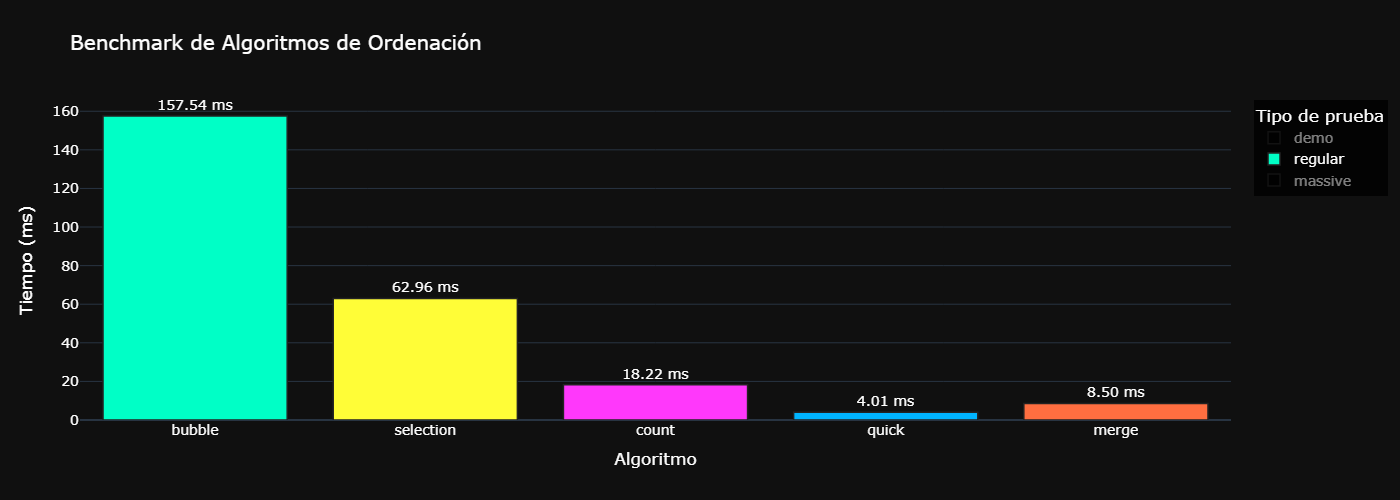

In [152]:
fig

#### Resultado por prueba masiva $\rightarrow$ 10,000 datos ordenados

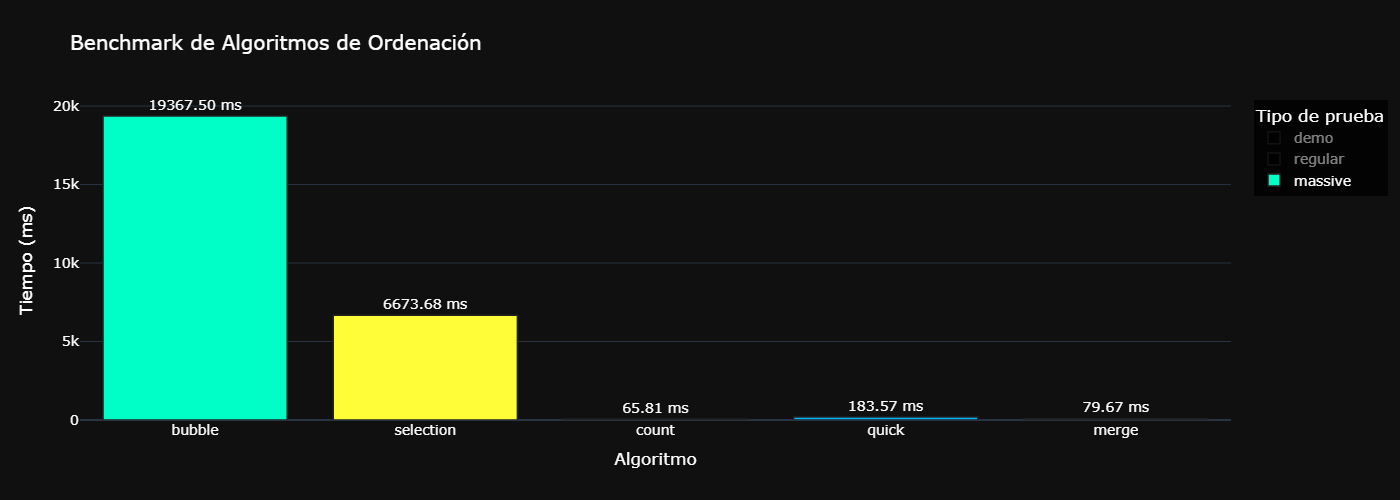

In [153]:
fig



## 4. Discussion

Los resultados obtenidos son consistentes con el análisis teórico de complejidad.

Los algoritmos Bubble Sort y Selection Sort presentan un comportamiento cuadrático \(O(n^2)\), lo que los hace poco eficientes para conjuntos de datos grandes. Sin embargo, su simplicidad los convierte en herramientas útiles para fines educativos.

Por otro lado, Merge Sort muestra un comportamiento mucho más eficiente, con complejidad \(O(n \log n)\), lo que se refleja en tiempos de ejecución significativamente menores para tamaños grandes.

En el caso del algoritmo Sweep Line, su eficiencia depende del ordenamiento de eventos, por lo que hereda la complejidad de Merge Sort. Esto lo convierte en una solución óptima para el problema de clientes simultáneos.

Una observación importante es que la correcta representación de los eventos (uso de +1 y -1) permite resolver el problema de manera elegante sin necesidad de estructuras adicionales complejas.

---

## 5. Conclusion

Al inicio de esta actividad me sentí confiado, ya que anteriormente había trabajado con este tipo de algoritmos. Sin embargo, al comenzar a implementarlos desde cero, noté que el proceso requería más esfuerzo del esperado.

En mi experiencia laboral suelo utilizar funciones de ordenamiento ya optimizadas, lo que facilita mucho el trabajo. No obstante, al regresar a lo básico, se vuelve evidente que estas funciones encapsulan una lógica más compleja, donde cada decisión en la implementación impacta directamente en la eficiencia.

Este ejercicio me permitió valorar la importancia de comprender los fundamentos, y cómo incluso problemas aparentemente simples pueden implicar un análisis más profundo cuando se consideran aspectos como la optimización de recursos y el diseño de algoritmos.